In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "content/drive/MyDrive/GT_SEM5/COMBINED_TOMATO_DATASET.zip"

print(zip_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
content/drive/MyDrive/GT_SEM5/COMBINED_TOMATO_DATASET.zip


In [ ]:
# Check the combined dataset ZIP

import os

zip_path = "/content/drive/MyDrive/GT_SEM5/COMBINED_TOMATO_DATASET.zip"

print("Dataset found:", os.path.exists(zip_path))

Dataset found: True


In [ ]:
# Extract the combined dataset

!unzip -q "/content/drive/MyDrive/GT_SEM5/COMBINED_TOMATO_DATASET.zip" -d "/content"

print("Dataset extracted successfully!")

replace /content/content/COMBINED_TOMATO_DATASET/Tomato___Spider_mites Two-spotted_spider_mite/77a3496e-25d7-4f1d-9a6c-b66c15cc2088___Com.G_SpM_FL 8485.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset extracted successfully!


In [ ]:
# Set the combined dataset path

dataset_path = "/content/content/COMBINED_TOMATO_DATASET"

print("Dataset path:", dataset_path)

Dataset path: /content/content/COMBINED_TOMATO_DATASET


In [ ]:
# Check the extracted dataset

!ls "/content/content/COMBINED_TOMATO_DATASET"

 Tomato___Bacterial_spot   Tomato___Septoria_leaf_spot
 Tomato___Early_blight	  'Tomato___Spider_mites Two-spotted_spider_mite'
 Tomato___healthy	   Tomato___Tomato_mosaic_virus
 Tomato___Late_blight	   Tomato___Tomato_Yellow_Leaf_Curl_Virus
 Tomato___Leaf_Mold


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# Display the classes

import os

classes = sorted(os.listdir(dataset_path))

print("Number of classes:", len(classes))

for class_name in classes:
    print(class_name)

Number of classes: 9
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [ ]:
# Count images in each class

import os

class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

print("Image count for each class:\n")

for class_name, count in class_counts.items():
    print(class_name, ":", count)

print("\nTotal images:", sum(class_counts.values()))

Image count for each class:

Tomato___Bacterial_spot : 1803
Tomato___Early_blight : 879
Tomato___Late_blight : 1628
Tomato___Leaf_Mold : 846
Tomato___Septoria_leaf_spot : 1557
Tomato___Spider_mites Two-spotted_spider_mite : 1343
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 4356
Tomato___Tomato_mosaic_virus : 343
Tomato___healthy : 1328

Total images: 14083


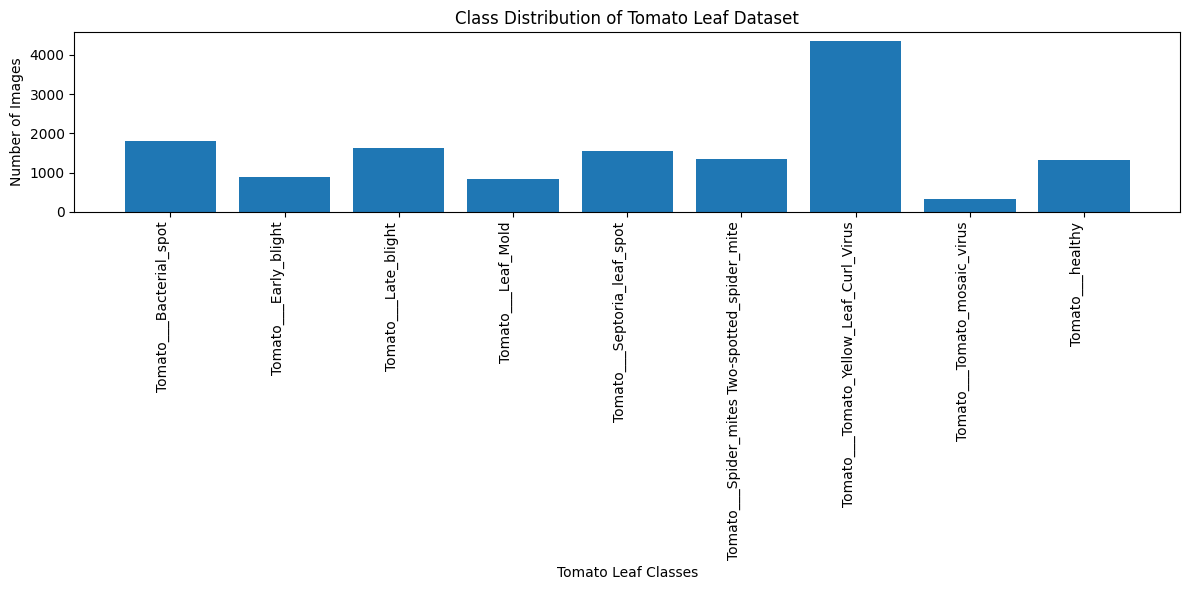

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Tomato Leaf Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Tomato Leaf Dataset")

plt.xticks(rotation=90, ha="right")
plt.tight_layout()

plt.show()

Tomato___Bacterial_spot : (256, 256)
Tomato___Early_blight : (256, 256)
Tomato___Late_blight : (256, 256)
Tomato___Leaf_Mold : (256, 256)
Tomato___Septoria_leaf_spot : (256, 256)
Tomato___Spider_mites Two-spotted_spider_mite : (256, 256)
Tomato___Tomato_Yellow_Leaf_Curl_Virus : (256, 256)
Tomato___Tomato_mosaic_virus : (256, 256)
Tomato___healthy : (256, 256)


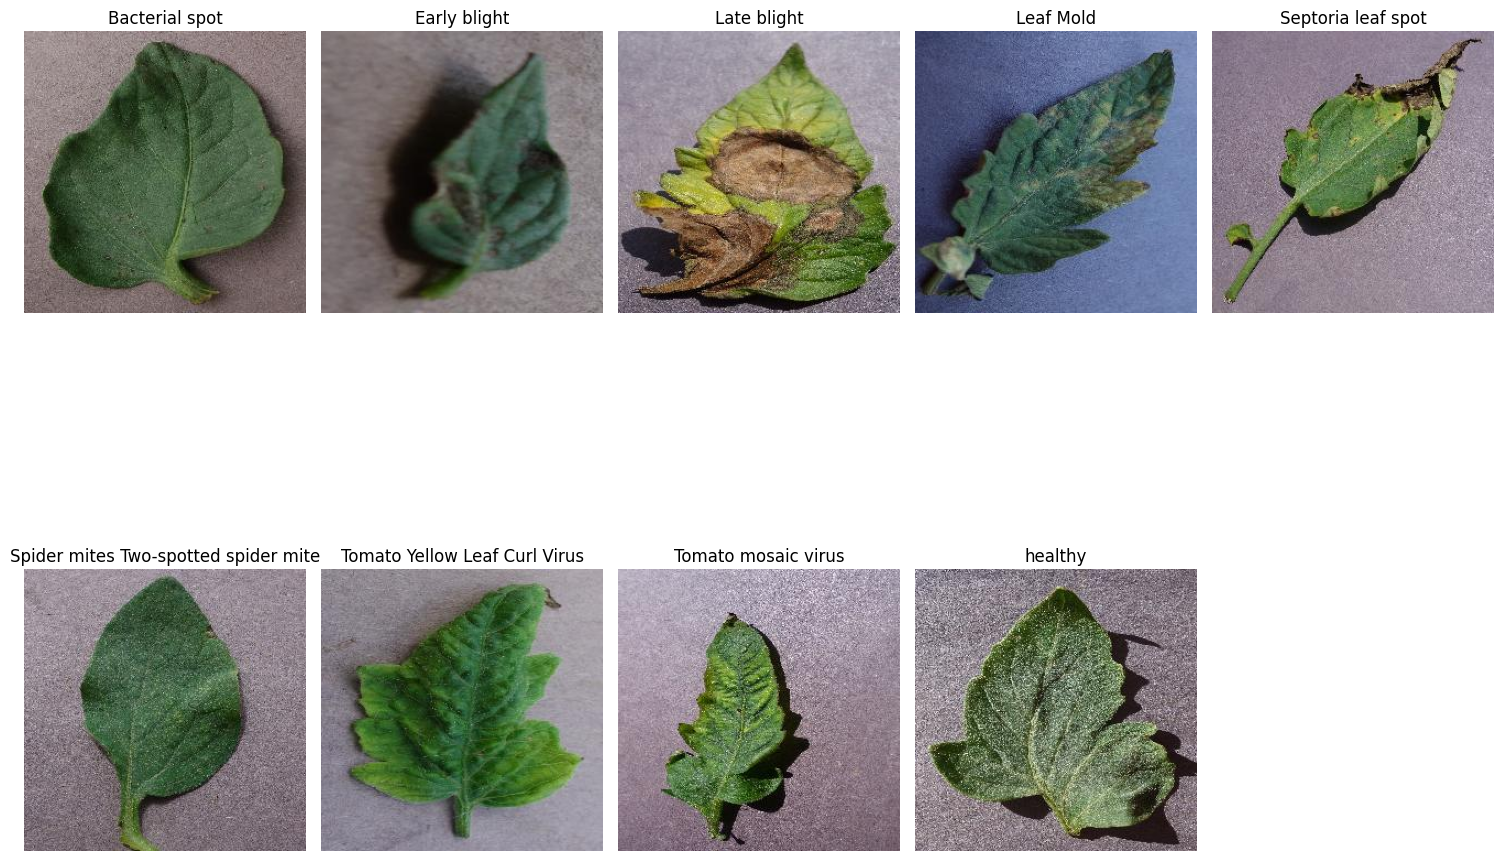

In [ ]:
# Display one sample image from each tomato leaf class

import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(15, 12))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    print(class_name, ":", image.size)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name.replace("Tomato___", "").replace("_", " "))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Load the dataset and resize images

import tensorflow as tf

img_size = (128, 128)
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

print("Dataset loaded successfully!")

Found 14083 files belonging to 9 classes.
Using 9859 files for training.
Found 14083 files belonging to 9 classes.
Using 4224 files for validation.
Dataset loaded successfully!


In [ ]:
# Split the remaining data into validation and test datasets

validation_data = validation_data.unbatch()

total_validation_images = 4224
test_size = total_validation_images // 2

validation_data = validation_data.shuffle(
    total_validation_images,
    seed=42,
    reshuffle_each_iteration=False
)

test_data = validation_data.take(test_size)
validation_data = validation_data.skip(test_size)

validation_data = validation_data.batch(batch_size)
test_data = test_data.batch(batch_size)

print("Validation and test datasets created successfully!")

Validation and test datasets created successfully!


In [ ]:
# Normalize pixel values from 0-255 to 0-1

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

])

In [ ]:
# Apply data augmentation to training images

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


In [ ]:
# Build the CNN model

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(9, activation="softmax")
])

print("CNN model created successfully!")

CNN model created successfully!


In [ ]:
# Display the CNN model structure

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,801 (12.61 MB)

 Trainable params: 3,305,801 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the CNN model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Train the CNN model

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=20
)

print("Model training completed!")

Epoch 1/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.5695 - loss: 1.2729 - val_accuracy: 0.6321 - val_loss: 1.0569
Epoch 2/20


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


309/309 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.7651 - loss: 0.7170 - val_accuracy: 0.7282 - val_loss: 0.7497
Epoch 3/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8134 - loss: 0.5380 - val_accuracy: 0.7869 - val_loss: 0.6063
Epoch 4/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8374 - loss: 0.4681 - val_accuracy: 0.7784 - val_loss: 0.6252
Epoch 5/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.8680 - loss: 0.3844 - val_accuracy: 0.8461 - val_loss: 0.4586
Epoch 6/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.8692 - loss: 0.3699 - val_accuracy: 0.8826 - val_loss: 0.3496
Epoch 7/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8897 - loss: 0.3201 - val_accuracy: 0.7841 - val_loss: 0.6874
Epoch 8/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.8987 - loss: 0.2884 - val_accuracy: 0.8291 - val_loss: 0.4909
Epoch 9/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9041 - loss: 0.2724 - val_accura

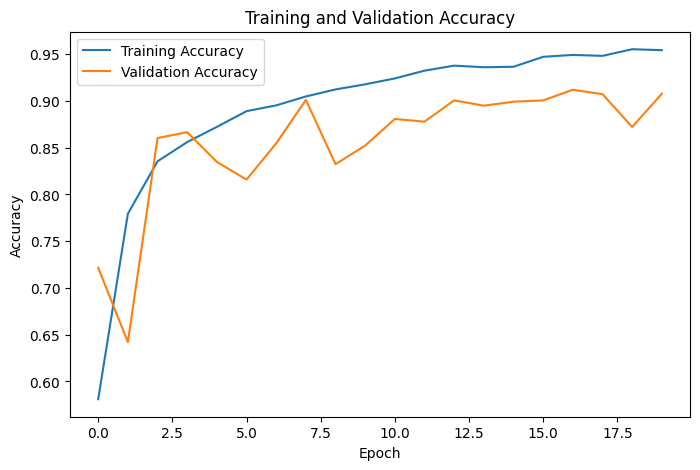

In [ ]:
# Plot training and validation accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

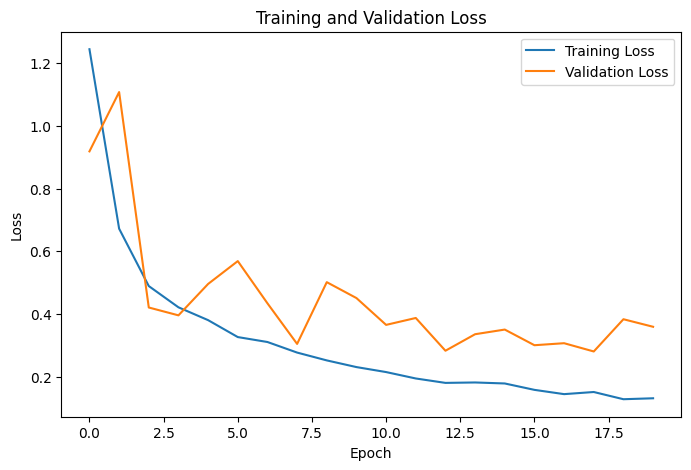

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [ ]:
# Evaluate the CNN on the unseen test dataset

test_loss, test_accuracy = model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9096 - loss: 0.3426
Test Accuracy: 0.9095643758773804
Test Loss: 0.34263667464256287


In [ ]:
# Generate the classification report

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.92      0.89      0.90       262
                        Tomato___Early_blight       0.67      0.84      0.75       116
                         Tomato___Late_blight       0.92      0.90      0.91       249
                           Tomato___Leaf_Mold       0.88      0.74      0.80       114
                  Tomato___Septoria_leaf_spot       0.80      0.93      0.86       232
Tomato___Spider_mites Two-spotted_spider_mite       0.91      0.96      0.94       212
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.94      0.97       672
                 Tomato___Tomato_mosaic_virus       0.97      0.84      0.90        44
                             Tomato___healthy       0.97      0.98      0.97       211

                                     accuracy                           0.91      2112
                                    macro

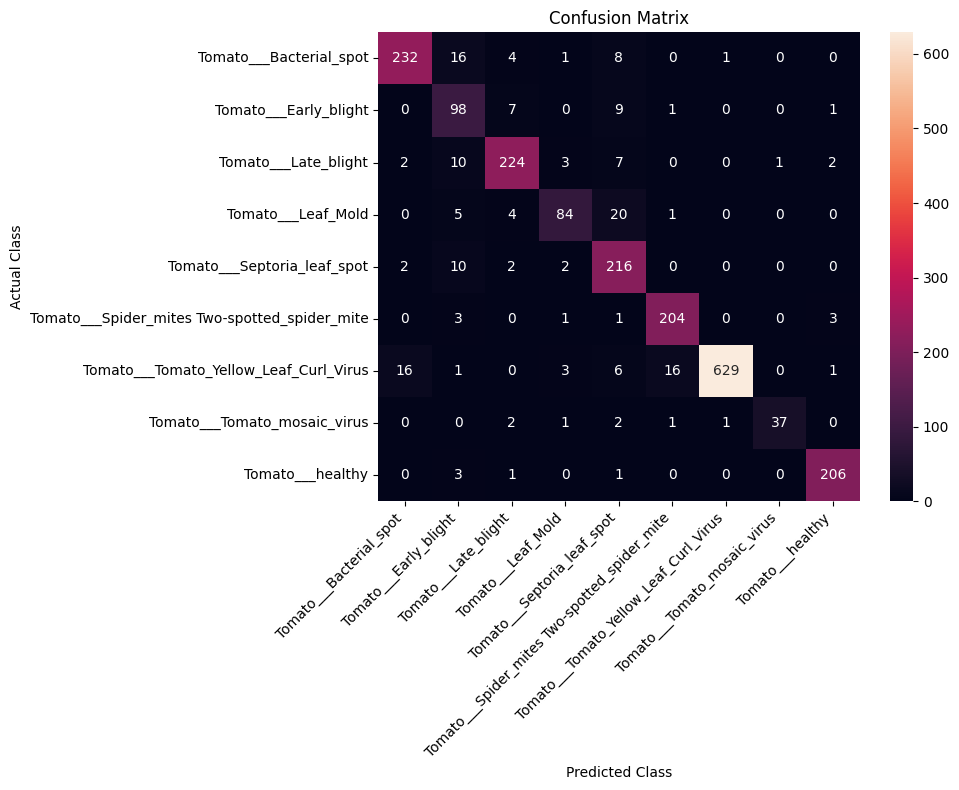

In [ ]:
# Display the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_data.class_names,
    yticklabels=train_data.class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [98]:
from google.colab import files

uploaded = files.upload()

Saving LateBlt09_06.jpg to LateBlt09_06.jpg


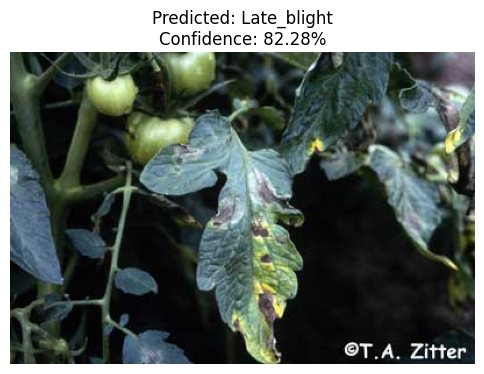

Predicted Class: Tomato___Late_blight
Confidence: 82.28 %


In [101]:
# Predict the disease and display the uploaded tomato leaf image

from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

image = load_img(image_path, target_size=(128, 128))
image_array = img_to_array(image)
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array, verbose=0)

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Display the uploaded image with prediction
plt.figure(figsize=(6, 6))
plt.imshow(load_img(image_path))
plt.axis("off")
plt.title(
    f"Predicted: {predicted_class.replace('Tomato___', '')}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")